# EDA: полный период, когорты и таргет

В `01_EDA_no_outliers.ipynb` и `02_EDA_extended.ipynb` уже разобраны:
- качество данных (пропуски/дубликаты/согласованность полей), распределения признаков, корреляции
- распределение GMV за 91-дневное окно (нулевая инфляция, Джини, перцентили, `log1p`);
- пользовательские RFM-агрегаты, воронка поиск/каталог/корзина, скорость и тренд активности (7д и 45д окна);
- недельная сезонность и стабильность (CV) дневной вовлечённости.

В этом ноутбуке:

1. Полный период (01.01.2025–13.02.2026): месячная динамика, календарные пики, рост базы пользователей.
2. Когортный анализ: когда пользователи впервые появляются и как долго остаются активными.
3. Собственно **построение таргета** (сумма GMV за 30 дней вперёд от cutoff) на нескольких cutoff-датах и его связь с историческими признаками


In [13]:
import gc
from datetime import date, timedelta

import numpy as np
import pandas as pd
import pyarrow
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Месячная динамика по всему периоду

In [10]:
daily_full = pd.read_parquet(
    "../data/train.parquet",
    engine="pyarrow",
    columns=["event_date", "user_id", "searches", "to_cart", "to_ord", "gmv"],
)
daily_full["event_date"] = pd.to_datetime(daily_full["event_date"])

monthly = (
    daily_full
    .assign(month=daily_full["event_date"].dt.to_period("M"))
    .groupby("month")
    .agg(
        active_users=("user_id", "nunique"),
        searches=("searches", "sum"),
        cart_items=("to_cart", "sum"),
        purchased_items=("to_ord", "sum"),
        gmv=("gmv", "sum"),
    )
)
monthly["gmv_per_active_user"] = monthly["gmv"] / monthly["active_users"]
display(monthly)


,active_users,searches,cart_items,purchased_items,gmv,gmv_per_active_user
month,,,,,,
2025-01,189446,5718814,1668206,402490,1.455842e+07,76.847355
2025-02,192145,5601636,1666826,416789,1.448472e+07,75.384330
2025-03,198363,6277483,1939421,489485,1.741812e+07,87.809313
2025-04,200550,6033422,1864253,474734,1.700565e+07,84.795055
2025-05,204063,6343306,1972598,510083,1.775749e+07,87.019648
2025-06,206828,6300647,2025111,535242,1.871582e+07,90.489757
2025-07,210631,6788809,2207231,591382,2.044194e+07,97.050938
2025-08,216313,7477355,2434206,671725,2.257182e+07,104.347960
2025-09,221598,7479407,2362893,642950,2.185236e+07,98.612636


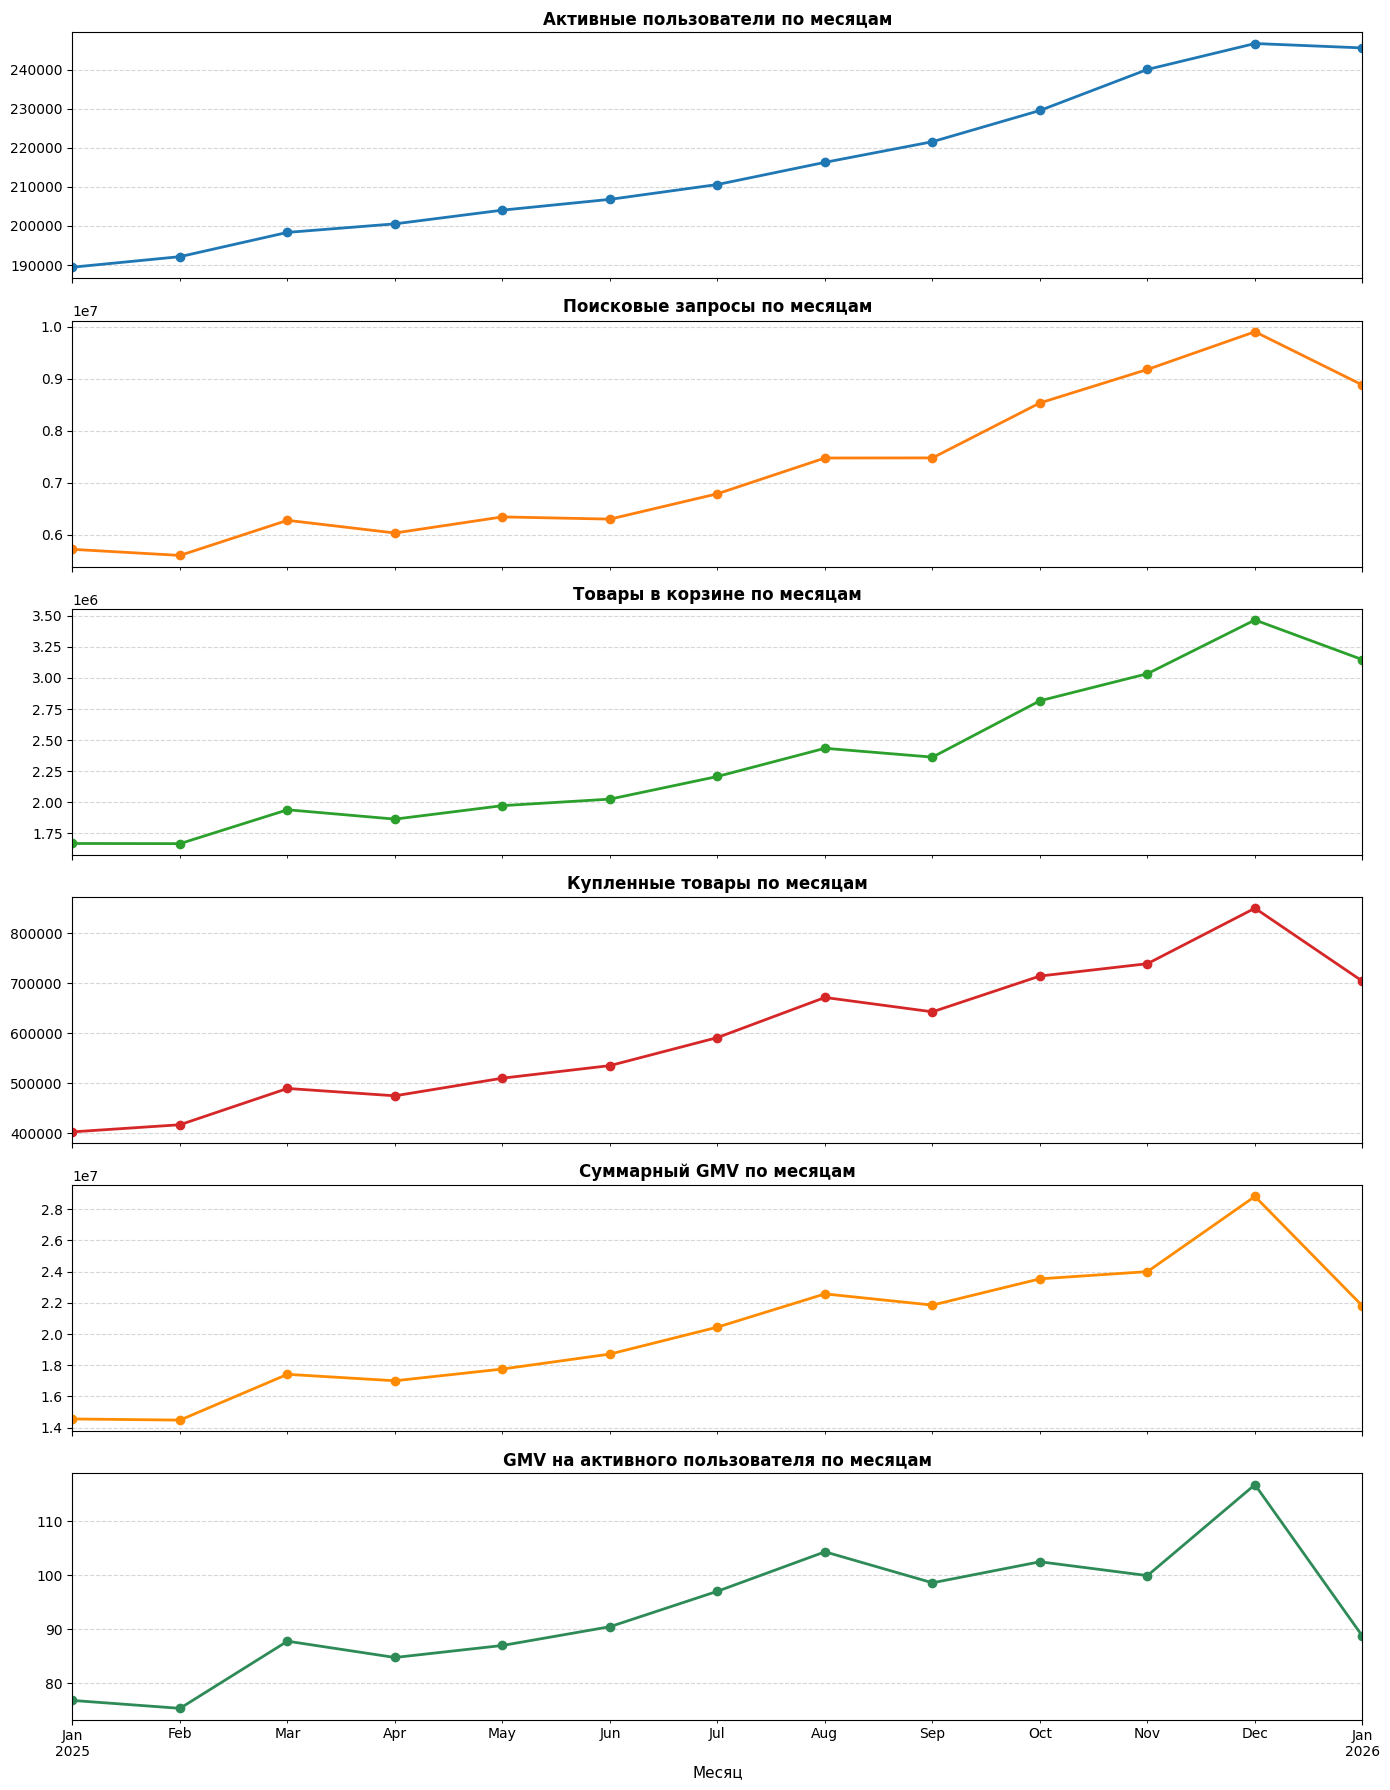

In [14]:
monthly_cleaned = monthly.loc[monthly.index < "2026-02-01"]  # отсекаем неполный февраль 2026 года

titles_map = {
    "active_users": "Активные пользователи",
    "searches": "Поисковые запросы",
    "cart_items": "Товары в корзине",
    "purchased_items": "Купленные товары",
    "gmv": "Суммарный GMV",
    "gmv_per_active_user": "GMV на активного пользователя"
}

colors_map = {
    "active_users": "#1f77b4",
    "searches": "#ff7f0e",
    "cart_items": "#2ca02c",
    "purchased_items": "#d62728",
    "gmv": "darkorange",
    "gmv_per_active_user": "seagreen"
}

columns = list(titles_map.keys())
fig, axes = plt.subplots(len(columns), 1, figsize=(14, 18), sharex=True)

for i, col in enumerate(columns):
    monthly_cleaned[col].plot(
        ax=axes[i],
        marker="o",
        color=colors_map[col],
        linewidth=2
    )

    axes[i].set_title(f"{titles_map[col]} по месяцам", fontsize=12, fontweight="bold")
    axes[i].grid(True, linestyle="--", alpha=0.5)

plt.xlabel("Месяц", fontsize=11)
plt.tight_layout()
plt.show()


### Замечания

1. Общий восходящий тренд: по всем ключевым графикам наблюдается выраженный восходящий тренд на протяжении всего года, что, вероятно, связано с ростом сервиса. Январские показатели 2026 года значительно превышают январь 2025 года.

2. Ярко выраженный предновогодний пик: декабрь демонстрирует абсолютный рекорд по всем метрикам за исследуемый период, что, вероятно, обусловлено массовой закупкой подарков к Новому году и проведением финальных зимних распродаж.

3. Не ярко выраженные локальные максимумы (март и август).
* После закономерного январско-февральского затишья в марте наблюдается заметный всплеск активности. Помимо общего восстановления потребительской активности, ключевым фактором может выступать 8 марта.
* В августе фиксируется ещё одна вершина. Это может быть связано с подготовкой школьников/студентов к новому учебному году.

## 2. Дневной ряд по всему периоду с разметкой праздников

Строим полный дневной GMV-ряд и отмечаем празники [23 февраля, 8 марта, 1 сентября, 11 ноября (день шоппинга), Новый год], чтобы явно увидеть форму пиков (длительность, асимметрия)

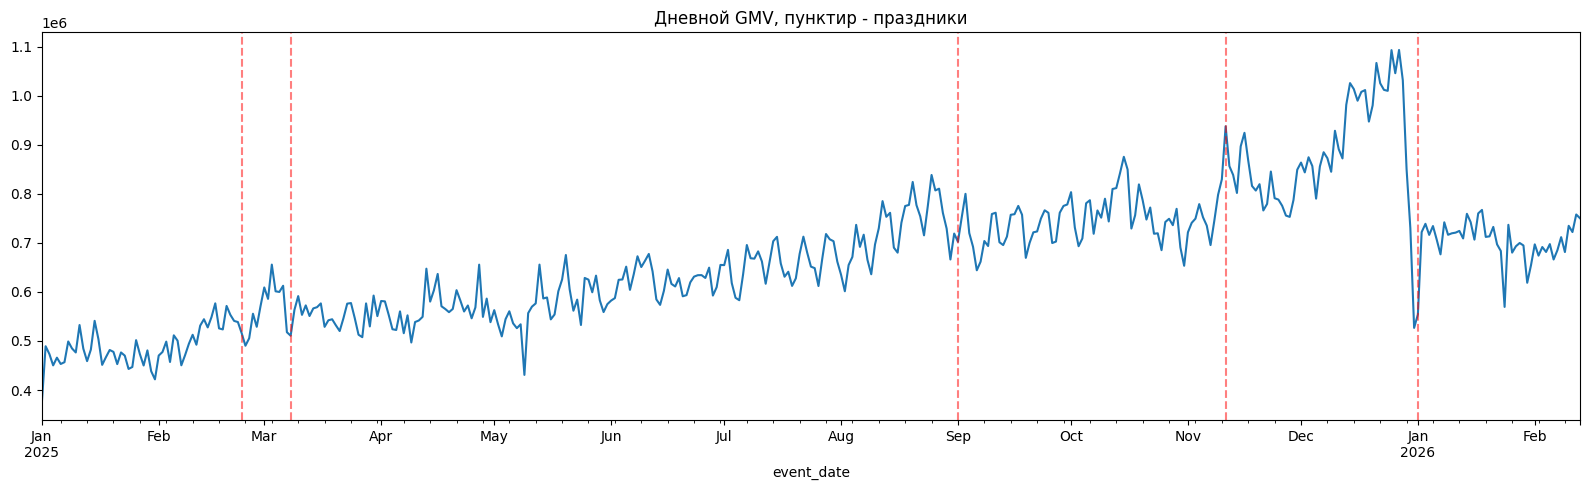

In [17]:
daily_gmv_full = daily_full.groupby("event_date")["gmv"].sum()

fig, ax = plt.subplots(figsize=(16, 5))
daily_gmv_full.plot(ax=ax)

for d in [date(2025, 2, 23), date(2025, 3, 8), date(2025, 9, 1), date(2025, 11, 11), date(2026, 1, 1)]:
    ax.axvline(pd.Timestamp(d), color="red", linestyle="--", alpha=0.5)

ax.axvspan(pd.Timestamp(date(2026, 2, 14)), pd.Timestamp(date(2026, 2, 13)) + pd.Timedelta(days=1),
            alpha=0)
ax.set_title("Дневной GMV, пунктир - праздники")
plt.tight_layout()
plt.show()


### Замечания

1. Перед 23 февраля, 8 марта, 1 сентября, 1 января наблюдается рост дневного GMV. При этом непосредственно в день празника показатель падает.

2. Прямо в день шопинга 11 ноября (обычно устраиваются распродажи) виден локальный максимум дневного GMV. Сразу же после виден ещё один пик, который, вероятно, связан с тем, что распродажи действуют не один день, а несколько.

Вывод: в календарном контексте нужно добавить признаки, связанные с празниками (период перед/после праздников), общепринятые дни распродаж

## 3. Когортный анализ: когда пользователи впервые появляются

In [45]:
first_seen = (
    daily_full.groupby("user_id")["event_date"].min()
    .rename("first_seen")
)
cohort_month = first_seen.dt.to_period("M").rename("cohort_month")

cohort_sizes = cohort_month.value_counts().sort_index()
display(cohort_sizes)


,count
cohort_month,
2025-01,189446
2025-02,14816
2025-03,8549
2025-04,5528
2025-05,4418
2025-06,4071
2025-07,3941
2025-08,4051
2025-09,3759


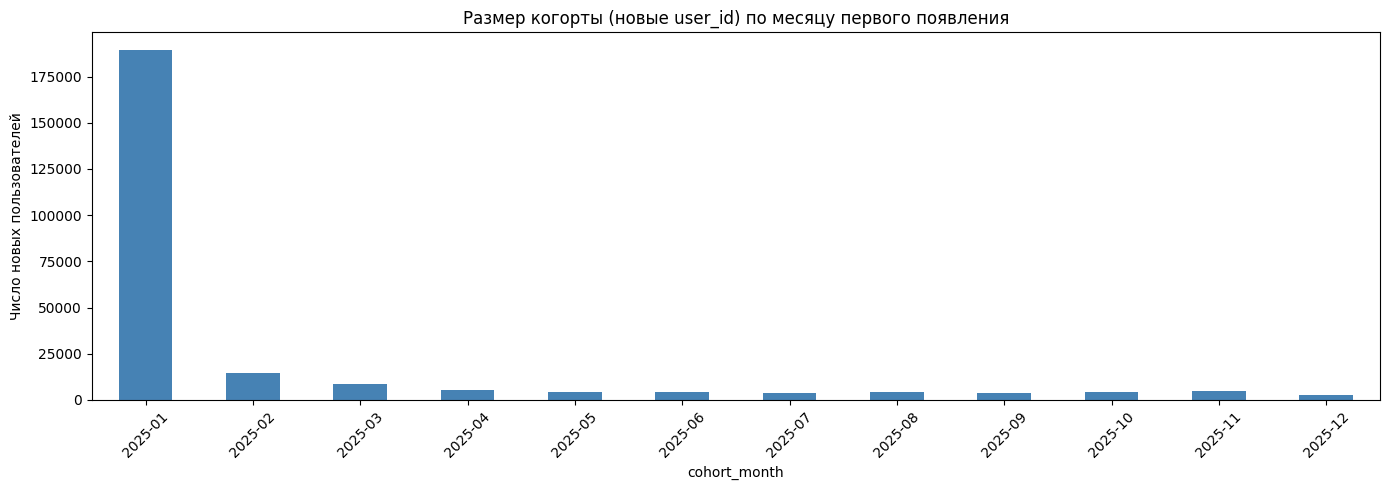

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))
cohort_sizes.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Размер когорты (новые user_id) по месяцу первого появления")
ax.set_ylabel("Число новых пользователей")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Разбили пользователей на группы по месяцу первого появления в датасете.
* 190 тысяч пользователей (76% от общего числа) были активны уже в январе 2025 года
* В феврале-апреле количество новых пользователей выше, чем в следующих месяцах. Это скорее всего связано с тем, что в это время активизировались многие старые пользователи, которые ещё не были активны с начала года.
* Начиная с мая и до конца года наблюдается в среднем около 4 тысяч новых пользователей в месяц. Скорее всего подавляющее большинство этих пользователей действительно новые, поскольку влияние активизирующихся старых пользователей уже должно было значительно сократиться.

In [46]:
activity_month = daily_full[["user_id", "event_date"]].drop_duplicates()
activity_month["month"] = activity_month["event_date"].dt.to_period("M")
activity_month = activity_month.merge(cohort_month, left_on="user_id", right_index=True)
activity_month["month_offset"] = (
    (activity_month["month"] - activity_month["cohort_month"]).apply(lambda x: x.n)
)

retention = (
    activity_month.groupby(["cohort_month", "month_offset"])["user_id"].nunique()
    .unstack("month_offset")
)
retention_pct = retention.div(retention[0], axis=0) * 100
display(retention_pct.round(1))


month_offset,0,1,2,3,4,5,6,7,8,9,10,11,12,13
cohort_month,,,,,,,,,,,,,,
2025-01,100.0,93.6,94.0,93.5,93.6,93.5,93.6,94.4,95.1,96.3,98.0,99.1,98.8,92.9
2025-02,100.0,79.3,77.1,77.8,78.2,79.4,81.6,83.9,88.7,93.8,97.5,96.5,84.4,NaN
2025-03,100.0,75.5,75.5,75.5,77.1,80.2,81.6,86.5,92.9,97.2,96.5,84.0,NaN,NaN
2025-04,100.0,77.1,73.9,76.6,78.1,80.8,85.6,93.1,97.4,96.2,83.6,NaN,NaN,NaN
2025-05,100.0,78.5,77.6,80.4,81.9,85.1,92.6,97.4,96.2,83.3,NaN,NaN,NaN,NaN
2025-06,100.0,82.7,82.0,82.9,87.1,93.3,97.5,96.9,83.6,NaN,NaN,NaN,NaN,NaN
2025-07,100.0,85.2,83.8,86.9,93.5,97.1,96.8,83.4,NaN,NaN,NaN,NaN,NaN,NaN
2025-08,100.0,87.8,88.2,93.8,97.9,96.3,84.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,100.0,90.1,93.4,97.2,97.3,83.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


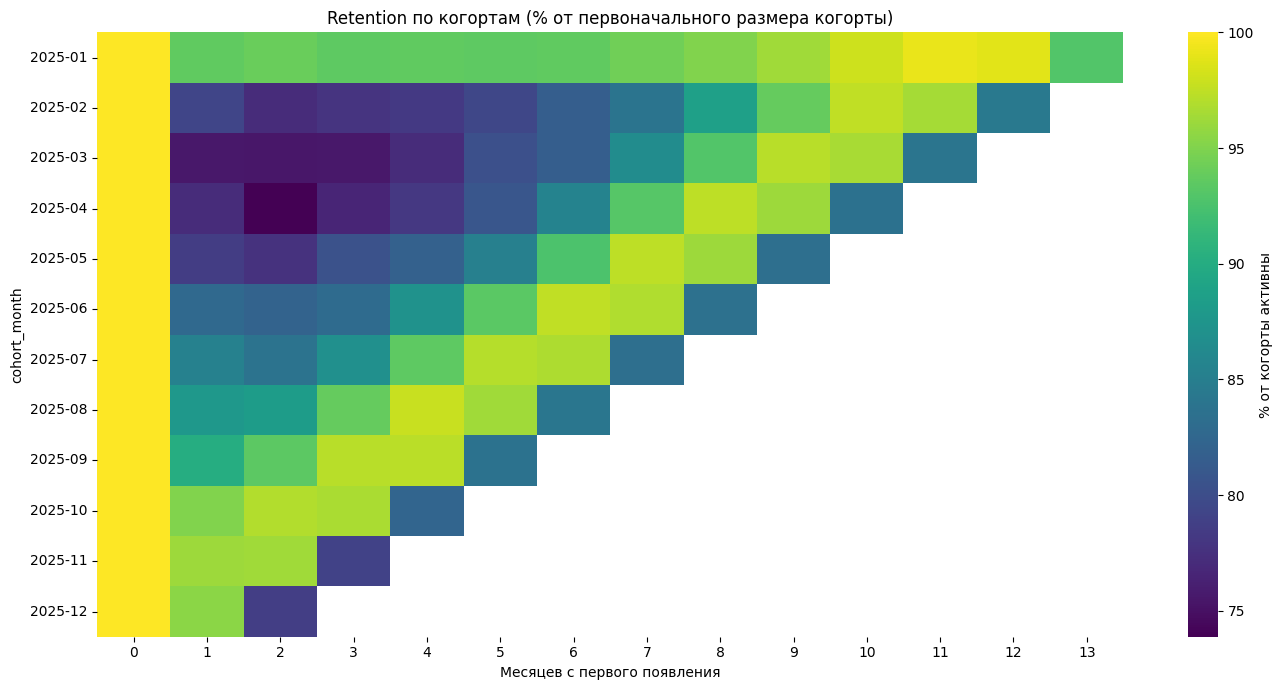

6365

In [25]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(retention_pct, annot=False, cmap="viridis", ax=ax, cbar_kws={"label": "% от когорты активны"})
ax.set_title("Retention по когортам (% от первоначального размера когорты)")
ax.set_xlabel("Месяцев с первого появления")
plt.tight_layout()
plt.show()

del activity_month
gc.collect();


**Retention (удержание)** — это маркетинговая метрика, которая показывает способность бизнеса сохранять своих клиентов или пользователей в течение определенного времени

### Замечания

* **Первая когорта (2025-01)** держится на аномально высоком уровне (93–99%) почти без просадки, так как в неё попали пользователи, активные ещё до старта датасета (лояльное ядро аудитории).

* **Основной паттерн — сезонная волна.** Retention растёт не потому, что
пользователи «возвращаются» с возрастом когорты, а потому что **октябрь–декабрь** — в эти месяцы активность
подскакивает у *всех* когорт одновременно, независимо от их возраста. Это видно по диагонали таблицы: для любой когорты сдвиг, попадающий на ноябрь-декабрь, даёт 93–99%.

* **Для прогноза (14.02–15.03.2026):** этот период идёт сразу после пикового сезона, поэтому стоит ожидать возврата активности к базовому несезонному уровню (~75–85%). Ориентир — аналогичный период прошлого года (февраль–март 2025).

## 4. Построение target и его связь с историей

Строим target -- **сумму `gmv` за 30 дней после cutoff** -- на пробной cutoff-дате в середине периода, и смотрим:
- какая доля пользователей, бывших активными в истории, дают нулевой target (аналог оттока/паузы);
- как target соотносится с агрегатами по истории (например, GMV за предыдущие 30 дней);

In [26]:
def user_history_features(df, cutoff, lookback_days=30):
    start = pd.Timestamp(cutoff) - pd.Timedelta(days=lookback_days - 1)
    hist = df[(df["event_date"] >= start) & (df["event_date"] <= pd.Timestamp(cutoff))]
    feats = hist.groupby("user_id").agg(
        gmv_lookback=("gmv", "sum"),
        active_days_lookback=("event_date", "nunique"),
        last_activity=("event_date", "max"),
    )
    feats["recency_days"] = (pd.Timestamp(cutoff) - feats["last_activity"]).dt.days
    return feats.drop(columns="last_activity")


def user_future_target(df, cutoff, horizon_days=30):
    start = pd.Timestamp(cutoff) + pd.Timedelta(days=1)
    end = pd.Timestamp(cutoff) + pd.Timedelta(days=horizon_days)
    fut = df[(df["event_date"] >= start) & (df["event_date"] <= end)]
    return fut.groupby("user_id")["gmv"].sum().rename("target_gmv_30d")


probe_cutoff = date(2025, 9, 15)  # пробный cutoff -- 15 сентября 2025 года
hist_feats = user_history_features(daily_full, probe_cutoff, lookback_days=30)
target = user_future_target(daily_full, probe_cutoff, horizon_days=30)

probe = hist_feats.join(target, how="outer").fillna(0)
probe.shape, probe["target_gmv_30d"].eq(0).mean()

((233588, 4), np.float64(0.45397023819716764))

На основе среза данных от **15 сентября 2025 года** была проведена сегментация пользователей по их активности в ретроспективном периоде (30 дней до отсечки) и целевом периоде (30 дней после отсечки). Распределение представлено ниже.

In [33]:
was_active = probe["active_days_lookback"] > 0
has_future_sales = probe["target_gmv_30d"] > 0

group_a = probe[was_active & ~has_future_sales].shape[0]  # Были активны в прошлом месяце -> ничего не купили
group_b = probe[was_active & has_future_sales].shape[0]   # Были активны в прошлом месяце -> что-то купили
group_c = probe[~was_active & has_future_sales].shape[0]  # Были неактивны в прошлом месяце -> что-то купили ("проснулись")
group_d = probe[~was_active & ~has_future_sales].shape[0] # Неактивны в прошлом месяце -> ничего не купили ("спят")
total_users = probe.shape[0]

print("=== Структура пользователей в срезе ===")
print(f"Всего уникальных user_id в таблице probe: {total_users}\n")

print(f"Группа А (Ушедшие):     {group_a:<7} пользователей ({group_a / total_users:.2%}) — были активны в прошлом месяце, но ничего не купили в этом")
print(f"Группа Б (Постоянные):  {group_b:<7} пользователей ({group_b / total_users:.2%}) — были активны в прошлом месяце и купили что-то в этом")
print(f"Группа В (Проснувшиеся): {group_c:<7} пользователей ({group_c / total_users:.2%}) — были неактивны в прошлом месяце, но купили что-то в этом")
print(f"Группа Г (Спящие): {group_d:<7} пользователей ({group_d / total_users:.2%}) — были неактивны в прошлом месяце, ничего не купили в этом")

=== Структура пользователей в срезе ===
Всего уникальных user_id в таблице probe: 233588

Группа А (Ушедшие):     94583   пользователей (40.49%) — были активны в прошлом месяце, но ничего не купили в этом
Группа Б (Постоянные):  123998  пользователей (53.08%) — были активны в прошлом месяце и купили что-то в этом
Группа В (Проснувшиеся): 3548    пользователей (1.52%) — были неактивны в прошлом месяце, но купили что-то в этом
Группа Г (Спящие): 11459   пользователей (4.91%) — были неактивны в прошлом месяце, ничего не купили в этом


Общая доля нулевого таргета составляет ~45%. Это хорошее распределение для обучения классификатора в двухстадийной модели - искусственная балансировка классов не требуется.

Можно отметить, чтобы доля спонтанных возвратов к покупкам ("проснувшихся" клиентов) мала.

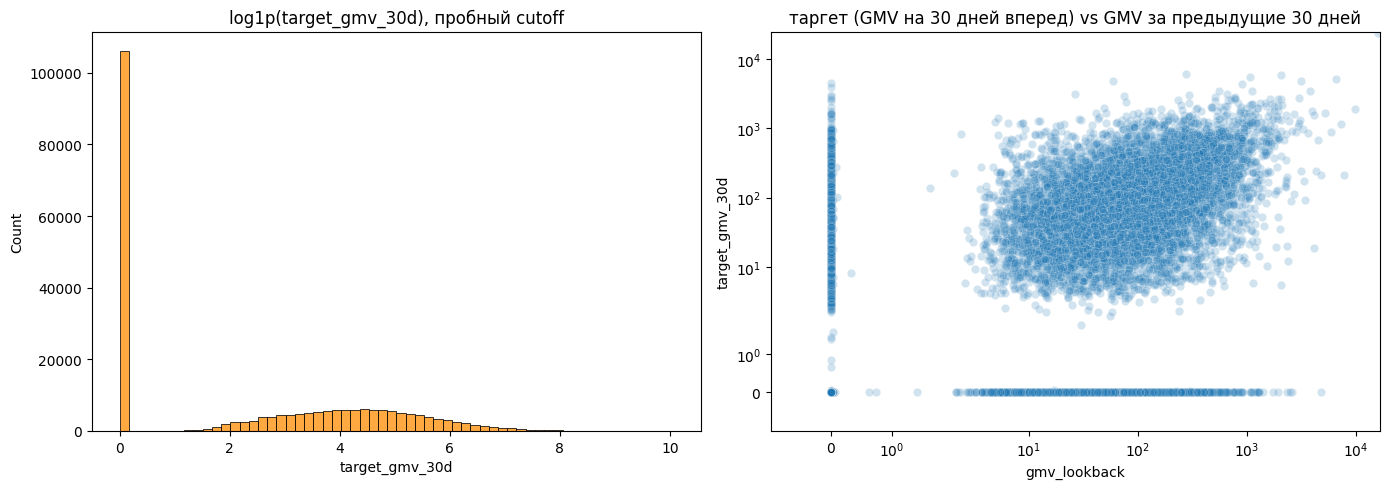

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(np.log1p(probe["target_gmv_30d"]), bins=60, ax=axes[0], color="darkorange")
axes[0].set_title("log1p(target_gmv_30d), пробный cutoff")

sns.scatterplot(
    x="gmv_lookback", y="target_gmv_30d",
    data=probe.sample(min(20_000, len(probe)), random_state=RANDOM_STATE),
    alpha=0.2, ax=axes[1],
)
axes[1].set_xscale("symlog")
axes[1].set_yscale("symlog")
axes[1].set_xlim(left=-1)
axes[1].set_ylim(bottom=-1)
axes[1].set_title("таргет (GMV на 30 дней вперед) vs GMV за предыдущие 30 дней")

plt.tight_layout()
plt.show()

In [48]:
corr_recency = probe[["gmv_lookback", "active_days_lookback", "recency_days", "target_gmv_30d"]].corr()
display(corr_recency)

,gmv_lookback,active_days_lookback,recency_days,target_gmv_30d
gmv_lookback,1.000000,0.331970,-0.132971,0.464498
active_days_lookback,0.331970,1.000000,-0.433383,0.261917
recency_days,-0.132971,-0.433383,1.000000,-0.116445
target_gmv_30d,0.464498,0.261917,-0.116445,1.000000


Данная таблица показывает силу и направление линейной взаимосвязи между историческими признаками (за прошлые 30 дней) и целевой переменной (за будущие 30 дней).

#### Определения

* **`gmv_lookback`** — GMV пользователя за предыдущие 30 дней до даты отсечки.
* **`active_days_lookback`** — число дней, в которые пользователь совершал действия на платформе за предыдущие 30 дней.
* **`recency_days`** — количество дней, прошедших с момента последней активности пользователя до даты отсечки.
* **`target_gmv_30d`** — GMV за следующие 30 дней после даты отсечки.

#### Влияние признаков на целевую переменную (`target_gmv_30d`)
* **`gmv_lookback` (`+0.464`) — Умеренная положительная корреляция:** Пользователи, которые много тратили в прошлом месяце, с высокой вероятностью продолжат тратить большие суммы и в следующем.
* **`active_days_lookback` (`+0.262`) — Слабая положительная корреляция:** Частота визитов и активность в прошлом месяце положительно влияют на будущие траты, но связь слабее, чем у прошлых чеков.
* **`recency_days` (`-0.116`) — Слабая отрицательная корреляция:** Чем *больше* дней пользователь отсутствует (растет `recency`), тем *меньше* денег он приносит в будущем (падает `target_gmv`). Клиенты, заходившие давно, склонны к окончательному оттоку.

## 5. Устойчивость картины target на разных cutoff'ах

Одного пробного среза недостаточно: повторяем построение target на нескольких cutoff-датах (разный сезон, разная удалённость от Нового года) и сравниваем долю нулевого таргета и медиану среди положительного таргета.

In [49]:
probe_cutoffs = [date(2025, i, 15) for i in range(1, 12)]

summary_rows = []
for c in probe_cutoffs:
    hf = user_history_features(daily_full, c, lookback_days=30)
    tg = user_future_target(daily_full, c, horizon_days=30)
    j = hf.join(tg, how="outer").fillna(0)
    active_mask = j["active_days_lookback"] > 0
    summary_rows.append({
        "cutoff": c,
        "n_active_history": int(active_mask.sum()),
        "zero_target_share_active": j.loc[active_mask, "target_gmv_30d"].eq(0).mean(),
        "median_target_if_positive": j.loc[j["target_gmv_30d"] > 0, "target_gmv_30d"].median(),
    })

cutoff_summary = pd.DataFrame(summary_rows)
display(cutoff_summary)

,cutoff,n_active_history,zero_target_share_active,median_target_if_positive
0,2025-01-15,168132,0.492785,63.146277
1,2025-02-15,191060,0.487454,68.295401
2,2025-03-15,195725,0.501612,65.434450
3,2025-04-15,199281,0.499616,65.490139
4,2025-05-15,201556,0.484238,67.685880
5,2025-06-15,205457,0.471213,69.006404
6,2025-07-15,208103,0.452920,70.755520
7,2025-08-15,212461,0.435360,72.846000
8,2025-09-15,218581,0.432714,71.040422
9,2025-10-15,225114,0.427694,68.587079


* Доля нулевого таргета среди активных в предыдущем месяце пользователей колеблется между 0.41 и 0.5
* Медиана среди положительного таргета находится между 63 и 72

Очевидно, при валидации будем использовать несколько cutoff-дат, чтобы избежать переобучения